# Projet : Analyse spatiale des températures maximales en Île-de-France (Partie 1)

In [6]:
# Import des modules
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import folium

In [56]:
# Initialisation des dossiers du projet (raw, processed, outputs)
os.makedirs("../data/raw", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("../outputs/figures", exist_ok=True)

---

## 0. Introduction

### 1. Contexte et objectif

Les villes sont souvent confrontées à des phénomènes de concentration de chaleur, se traduisant par des températures plus élevées dans certains secteurs que dans d'autres.

Cela peut avoir des impacts importants, notamment sur la santé et la qualité de vie.

Dans ce contexte, l'objectif de ce projet est d'identifier les secteurs les plus chauds en Île-de-France à partir de données de température, et d’explorer les facteurs pouvant expliquer leur présence.


### 2. Cadre de l'étude

L'étude porte sur des données de températures issues de stations météorologiques situées en Île-de-France.  
L'analyse se concentre plus particulièrement sur les périodes de fortes chaleurs.


### 3. Données

Les données utilisées proviennent du jeu de données « [Données climatologiques de base quotidiennes](https://www.data.gouv.fr/datasets/donnees-climatologiques-de-base-quotidiennes) » disponible sur data.gouv.fr.  
Elles couvrent les départements d'Île-de-France, pour différentes stations météorologiques.  
Elles sont réparties en plusieurs fichiers, correspondant aux différents départements.  
Elles s'étendent de janvier 2025 à avril 2026 et sont de fréquence quotidienne.  
Elles contiennent notamment des informations de température.


### 4. Méthode

L'analyse repose sur les étapes suivantes :
* regroupement des différents fichiers en un seul jeu de données
* nettoyage et préparation des données
* exploration des températures
* identification des secteurs les plus chauds
* visualisation des résultats.


### 5. Résultats attendus

Les résultats seront notamment présentés sous forme de carte.

---

## 1. Import des données

### Chargement des données

On importe 8 fichiers, correspondant aux données météorologiques des 8 départements d'Île-de-France.

In [7]:
# Liste des numéros de départements
departements = [75, 77, 78, 91, 92, 93, 94, 95]
# Liste des noms des fichiers
files = [
    "Q_75_latest-2025-2026_RR-T-Vent.csv.gz",
    "Q_77_latest-2025-2026_RR-T-Vent.csv.gz",
    "Q_78_latest-2025-2026_RR-T-Vent.csv.gz",
    "Q_91_latest-2025-2026_RR-T-Vent.csv.gz", 
    "Q_92_latest-2025-2026_RR-T-Vent.csv.gz",
    "Q_93_latest-2025-2026_RR-T-Vent.csv.gz",
    "Q_94_latest-2025-2026_RR-T-Vent.csv.gz",
    "Q_95_latest-2025-2026_RR-T-Vent.csv.gz"    
]
# Liste des dataframes
dfs= []
path = "../data/raw/"
for dep, file in zip(departements, files):
    df = pd.read_csv(os.path.join(path, file), sep=";")
    df['departement'] = dep # Création d'une colonne "departement"
    dfs.append(df)
# Concaténer les dataframes
df_final = pd.concat(dfs, ignore_index=True)

### Vérification rapide des données

In [8]:
df_final.head()

,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,AAAAMMJJ,RR,QRR,TN,QTN,...,QFXI3S,DXI3S,QDXI3S,HXI3S,QHXI3S,DRR,QDRR,STATUS_FXI3S,STATUS_DXI3S,departement
0,75106001,LUXEMBOURG,48.844833,2.3385,50,20250101,13.3,1.0,4.6,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75
1,75106001,LUXEMBOURG,48.844833,2.3385,50,20250102,7.4,1.0,3.1,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75
2,75106001,LUXEMBOURG,48.844833,2.3385,50,20250103,0.2,1.0,-0.1,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75
3,75106001,LUXEMBOURG,48.844833,2.3385,50,20250104,10.7,1.0,-2.2,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75
4,75106001,LUXEMBOURG,48.844833,2.3385,50,20250105,2.2,1.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75


In [9]:
df_final.shape

(21868, 61)

In [10]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21868 entries, 0 to 21867
Data columns (total 61 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   NUM_POSTE     21868 non-null  int64  
 1   NOM_USUEL     21868 non-null  object 
 2   LAT           21868 non-null  float64
 3   LON           21868 non-null  float64
 4   ALTI          21868 non-null  int64  
 5   AAAAMMJJ      21868 non-null  int64  
 6   RR            20934 non-null  float64
 7   QRR           20939 non-null  float64
 8   TN            21804 non-null  float64
 9   QTN           21853 non-null  float64
 10  HTN           21682 non-null  float64
 11  QHTN          21745 non-null  float64
 12  TX            21804 non-null  float64
 13  QTX           21861 non-null  float64
 14  HTX           21700 non-null  float64
 15  QHTX          21769 non-null  float64
 16  TM            21779 non-null  float64
 17  QTM           21849 non-null  float64
 18  TNTXM         21801 non-nu

* Les types semblent globalement corrects, sauf la date (AAAAMMJJ) encodée en entier.
* La concaténation semble cohérente (61 colonnes).
* Toutes les variables semblent documentées, bien que certaines ne figurent pas dans le tableau principal mais dans des sections explicatives.
* Colonnes utiles identifiées : NOM_USUEL, LAT, LON, AAAAMMJJ, TX.
* La variable TX contient quelques valeurs manquantes.
* Les variables de moyenne (TM, TNTXM) ne sont pas retenues à ce stade, car l'analyse repose sur la moyenne des températures maximales sur la période étudiée.
* Les variables de qualité (commençant par “Q”) ne sont pas retenues à ce stade, leur utilisation nécessitant une analyse spécifique.


---

## 2. Nettoyage rapide

Une première étape de nettoyage consiste à sélectionner les variables utiles pour l'analyse.

### 2.1 Création d’une copie

In [11]:
df_final_clean = df_final.copy()

### 2.2 Sélection des variables

In [12]:
col_utiles = ["NOM_USUEL", "LAT", "LON", "AAAAMMJJ", "TX", "departement"]
df_final_clean = df_final_clean[col_utiles].copy()

In [13]:
# Vérification
df_final_clean.info()
df_final_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21868 entries, 0 to 21867
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   NOM_USUEL    21868 non-null  object 
 1   LAT          21868 non-null  float64
 2   LON          21868 non-null  float64
 3   AAAAMMJJ     21868 non-null  int64  
 4   TX           21804 non-null  float64
 5   departement  21868 non-null  int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 1.0+ MB


,NOM_USUEL,LAT,LON,AAAAMMJJ,TX,departement
0,LUXEMBOURG,48.844833,2.3385,20250101,9.0,75
1,LUXEMBOURG,48.844833,2.3385,20250102,5.2,75
2,LUXEMBOURG,48.844833,2.3385,20250103,5.5,75
3,LUXEMBOURG,48.844833,2.3385,20250104,11.5,75
4,LUXEMBOURG,48.844833,2.3385,20250105,13.2,75


### 2.3 Renommage des variables

In [14]:
df_final_clean = df_final_clean.rename(columns={
    "NOM_USUEL": "station",
    "LAT": "lat",
    "LON": "lon", 
    "AAAAMMJJ" : "date",
    "TX" : "temp_max"
})

In [15]:
# Vérification
df_final_clean.info()
df_final_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21868 entries, 0 to 21867
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   station      21868 non-null  object 
 1   lat          21868 non-null  float64
 2   lon          21868 non-null  float64
 3   date         21868 non-null  int64  
 4   temp_max     21804 non-null  float64
 5   departement  21868 non-null  int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 1.0+ MB


,station,lat,lon,date,temp_max,departement
0,LUXEMBOURG,48.844833,2.3385,20250101,9.0,75
1,LUXEMBOURG,48.844833,2.3385,20250102,5.2,75
2,LUXEMBOURG,48.844833,2.3385,20250103,5.5,75
3,LUXEMBOURG,48.844833,2.3385,20250104,11.5,75
4,LUXEMBOURG,48.844833,2.3385,20250105,13.2,75


### 2.4 Conversion des types

In [16]:
df_final_clean['date'] = pd.to_datetime(df_final_clean['date'], format="%Y%m%d")

In [17]:
# Vérification
df_final_clean.info()
df_final_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21868 entries, 0 to 21867
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   station      21868 non-null  object        
 1   lat          21868 non-null  float64       
 2   lon          21868 non-null  float64       
 3   date         21868 non-null  datetime64[ns]
 4   temp_max     21804 non-null  float64       
 5   departement  21868 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 1.0+ MB


,station,lat,lon,date,temp_max,departement
0,LUXEMBOURG,48.844833,2.3385,2025-01-01,9.0,75
1,LUXEMBOURG,48.844833,2.3385,2025-01-02,5.2,75
2,LUXEMBOURG,48.844833,2.3385,2025-01-03,5.5,75
3,LUXEMBOURG,48.844833,2.3385,2025-01-04,11.5,75
4,LUXEMBOURG,48.844833,2.3385,2025-01-05,13.2,75


### 2.5 Gestion des valeurs manquantes

On analyse la présence de valeurs manquantes et leur impact sur la variable d'intérêt.

In [18]:
df_final_clean.isna().sum()

station         0
lat             0
lon             0
date            0
temp_max       64
departement     0
dtype: int64

In [19]:
df_final_clean.isna().mean() *100

station        0.000000
lat            0.000000
lon            0.000000
date           0.000000
temp_max       0.292665
departement    0.000000
dtype: float64

Les valeurs manquantes étant peu nombreuses, elles seront supprimées pour la suite de l'analyse.

In [20]:
df_final_clean = df_final_clean.dropna()

In [21]:
# Vérification
df_final_clean.info()
df_final_clean.head()

<class 'pandas.core.frame.DataFrame'>
Index: 21804 entries, 0 to 21867
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   station      21804 non-null  object        
 1   lat          21804 non-null  float64       
 2   lon          21804 non-null  float64       
 3   date         21804 non-null  datetime64[ns]
 4   temp_max     21804 non-null  float64       
 5   departement  21804 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 1.2+ MB


,station,lat,lon,date,temp_max,departement
0,LUXEMBOURG,48.844833,2.3385,2025-01-01,9.0,75
1,LUXEMBOURG,48.844833,2.3385,2025-01-02,5.2,75
2,LUXEMBOURG,48.844833,2.3385,2025-01-03,5.5,75
3,LUXEMBOURG,48.844833,2.3385,2025-01-04,11.5,75
4,LUXEMBOURG,48.844833,2.3385,2025-01-05,13.2,75


### 2.6 Gestion des doublons

In [22]:
df_final_clean.duplicated().sum()

np.int64(0)

Aucun doublon n'est observé.

### 2.7 Sauvegarde des données nettoyées

Cette étape permet de réutiliser directement les données nettoyées dans la suite du projet sans relancer tout le traitement.

In [23]:
df_final_clean.to_csv("../data/processed/df_final_clean.csv", index=False)

---

## 3. Exploration des données

### 3.1 Rappel du jeu de données

Le jeu de données a été nettoyé et préparé en amont. Cette étape rappelle sa structure générale.

In [24]:
df_final_clean.info()
df_final_clean.head()

<class 'pandas.core.frame.DataFrame'>
Index: 21804 entries, 0 to 21867
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   station      21804 non-null  object        
 1   lat          21804 non-null  float64       
 2   lon          21804 non-null  float64       
 3   date         21804 non-null  datetime64[ns]
 4   temp_max     21804 non-null  float64       
 5   departement  21804 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(1), object(1)
memory usage: 1.2+ MB


,station,lat,lon,date,temp_max,departement
0,LUXEMBOURG,48.844833,2.3385,2025-01-01,9.0,75
1,LUXEMBOURG,48.844833,2.3385,2025-01-02,5.2,75
2,LUXEMBOURG,48.844833,2.3385,2025-01-03,5.5,75
3,LUXEMBOURG,48.844833,2.3385,2025-01-04,11.5,75
4,LUXEMBOURG,48.844833,2.3385,2025-01-05,13.2,75


### 3.2 Statistiques descriptives

Les statistiques descriptives donnent un premier aperçu des ordres de grandeur des variables.

In [25]:
df_final_clean['temp_max'].describe()

count    21804.000000
mean        16.402399
std          7.808423
min         -2.500000
25%         10.600000
50%         16.000000
75%         21.700000
max         41.100000
Name: temp_max, dtype: float64

* La température maximale moyenne est de 16,4°C, avec un écart-type de 7,8°C, indiquant une variabilité importante des températures.
* Les valeurs s'étendent de -2,5°C à 41,1°C, ce qui reflète la présence de conditions hivernales et estivales dans le jeu de données.
* 75% des valeurs sont inférieures à 21,7°C, ce qui indique que les températures élevées restent ponctuelles sur l'ensemble des données.

#### Point important 

Ces statistiques concernent l'ensemble des données disponibles (janvier 2025 à avril 2026). Une sélection saisonnière (mai à septembre) sera appliquée dans la suite de l'exploration afin de se concentrer sur la période pertinente pour l'étude des secteurs les plus chauds.


### 3.3 Analyse temporelle

On cherche à analyser l'évolution globale des températures dans le temps.   
Plusieurs stations étant mesurées pour une même date, on calcule la moyenne des températures maximales par jour.

In [26]:
# Série temporelle (moyenne journalière)
df_time = df_final_clean.groupby('date')['temp_max'].mean()
df_time.head()

date
2025-01-01     8.717021
2025-01-02     4.808511
2025-01-03     4.274468
2025-01-04    10.995745
2025-01-05    12.585106
Name: temp_max, dtype: float64

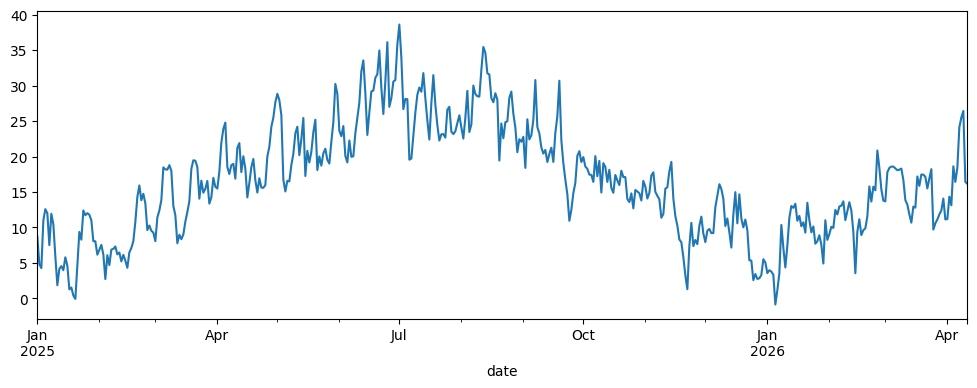

In [27]:
# Courbe
df_time.plot(figsize=(12,4));

L'évolution des températures présente un cycle annuel cohérent avec les variations climatiques attendues, avec des valeurs plus élevées en été et plus faibles en hiver.

Des variations journalières de l’ordre de quelques degrés sont observées, sans anomalies particulières.



### 3.4 Analyse spatiale


#### Analyse spatiale globale

On analyse les différences de températures entre Paris et la couronne selon deux approches : une comparaison globale et une analyse temporelle.

##### Comparaison globale

On compare les températures entre Paris et la couronne sur l'ensemble de la période (janvier 2025 à avril 2026), en considérant une moyenne globale.

On commence par définir une variable indiquant la zone (Paris ou Couronne).

In [28]:
# Création d'une variable zone
df_final_clean["zone"] = np.where(df_final_clean["departement"] == 75, "Paris", "Couronne")

In [29]:
# Vérification
print(df_final_clean["zone"].value_counts())
print()
print(df_final_clean[['departement', 'zone']].drop_duplicates())

zone
Couronne    19020
Paris        2784
Name: count, dtype: int64

       departement      zone
0               75     Paris
2784            77  Couronne
9772            78  Couronne
14888           91  Couronne
17674           92  Couronne
18140           93  Couronne
18606           94  Couronne
19072           95  Couronne


In [30]:
# Température moyenne par zone
temp_zone = df_final_clean.groupby('zone')['temp_max'].mean()

In [31]:
# Vérification
temp_zone

zone
Couronne    16.393181
Paris       16.465374
Name: temp_max, dtype: float64

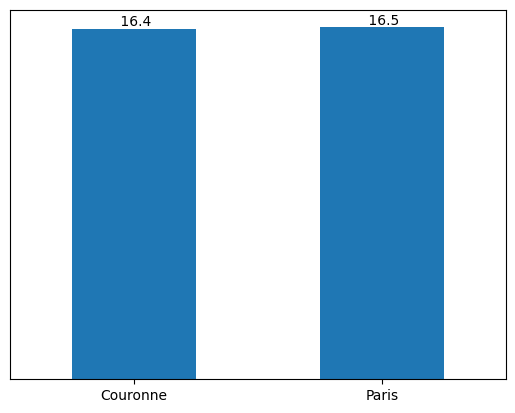

In [32]:
# Visualisation
ax = temp_zone.plot(kind="bar")
# tourner étiquettes axe x
plt.xticks(rotation=0)
# enlever label axe x
plt.xlabel(None)
# enlever graduations axe y
plt.yticks([])
# afficher valeurs au-dessus des barres
for i, v in enumerate(temp_zone):
    ax.text(i, v, f"{v : .1f}", ha='center', va="bottom")
    
plt.show()

Les températures maximales moyennes de Paris et de la couronne sont très proches, autour de 16,4 °C, ce qui suggère peu de différences à l'échelle globale.

##### Comparaison temporelle 

On compare l’évolution des températures entre Paris et la couronne en fonction du temps.

In [33]:
# Série temporelle des températures moyennes par zone 
temp_zone_time = df_final_clean.groupby(['date', 'zone'])['temp_max'].mean().unstack()

In [34]:
# Vérification 
temp_zone_time.head()

zone,Couronne,Paris
date,,
2025-01-01,8.741463,8.550000
2025-01-02,4.807317,4.816667
2025-01-03,4.212195,4.700000
2025-01-04,10.990244,11.033333
2025-01-05,12.568293,12.700000


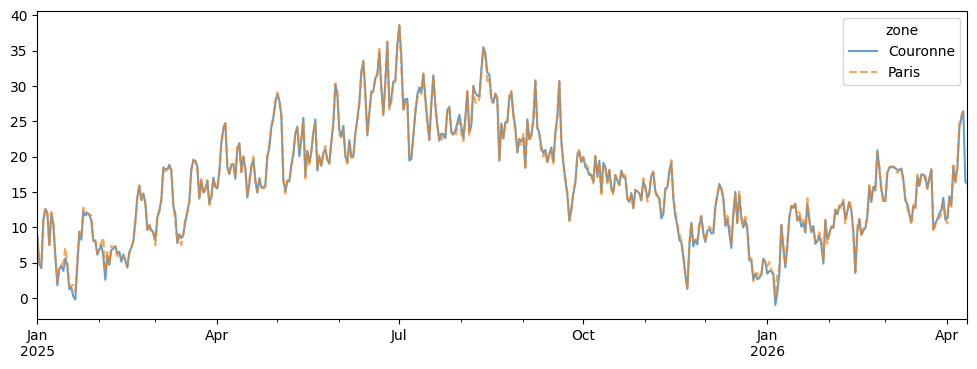

In [35]:
# Visualisation
ax = temp_zone_time.plot(figsize=(12,4), alpha=0.7, style=['-', '--'])
# enlever label axe x
plt.xlabel(None)

plt.show()

Les températures maximales de Paris et de la couronne présentent une évolution temporelle similaire, avec des variations de même amplitude.

#### Analyse spatiale locale

On analyse maintenant les différences entre stations au sein de chaque zone afin d'identifier les stations les plus chaudes.

##### Comparaison des stations par zone

In [36]:
# Températures moyennes par station dans chaque zone
temp_stations = df_final_clean.groupby(['zone', 'station'])['temp_max'].mean()
# Classement des stations par température moyenne dans chaque zone
temp_stations = temp_stations.reset_index()
temp_stations = temp_stations.sort_values(by=['zone', 'temp_max'], ascending=[True, False])

In [37]:
# Vérification
temp_stations

,zone,station,temp_max
31,Couronne,ST-MAUR,17.345279
22,Couronne,NEMOURS,17.298915
23,Couronne,NEUILLY-SUR-M.,17.297639
13,Couronne,LE PECQ,17.287768
17,Couronne,MAULE,17.234335
32,Couronne,SURESNES,17.222532
5,Couronne,CROUY-SUR-OURCQ,17.113305
0,Couronne,ACHERES,16.999356
6,Couronne,DONNEMARIE,16.967597
19,Couronne,MILLY-LA-FORET,16.934335


Les températures moyennes des stations varient entre environ 14,2°C et 17,6°C à Paris, et entre 14,4°C et 17,3°C en couronne. L'amplitude des températures entre stations apparaît ainsi comparable dans les deux zones.

##### Stations les plus chaudes par zone

On cherche à identifier les stations où les températures sont les plus élevées, afin de mettre en évidence les secteurs les plus chauds dans chaque zone.

In [38]:
#  Top 3 des stations les plus chaudes par zone
top3_paris = temp_stations[temp_stations['zone']=='Paris'].head(3)
top3_couronne = temp_stations[temp_stations['zone']=='Couronne'].head(3)

In [39]:
# Vérification
display(top3_paris)
print()
display(top3_couronne)

,zone,station,temp_max
43,Paris,LUXEMBOURG,17.586422
42,Paris,LONGCHAMP,16.928448
41,Paris,LARIBOISIERE,16.870474


,zone,station,temp_max
31,Couronne,ST-MAUR,17.345279
22,Couronne,NEMOURS,17.298915
23,Couronne,NEUILLY-SUR-M.,17.297639


Afin de mieux interpréter ces résultats, on représente les stations sur une carte, en mettant en évidence les plus chaudes.  

Les couleurs correspondent à des classes de température définies par des seuils simples (16 °C et 17 °C), permettant de distinguer visuellement les stations les plus chaudes.

In [40]:
# Carte des stations avec température moyenne

# création d'une carte centrée sur Paris
map_paris = folium.Map(location=[48.85, 2.35], zoom_start=10)
# température moyenne par station avec coordonnées géographiques
df_map = df_final_clean.groupby(['zone', 'station', 'lat', 'lon'])['temp_max'].mean().reset_index()
# ajout des stations sur la carte
def get_color(temp):
    if temp > 17:
        return "red"
    elif temp > 16:
        return "orange"
    else:
        return "yellow"
for _, row in df_map.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius = 4 + (row["temp_max"] - 14) * 2, # Taille des cercles = intensité
        color=get_color(row['temp_max']), # Couleur = niveau de température
        fill_opacity=0.6,
        tooltip=f"{row['zone']} - {row['station']} - {row['temp_max']:.1f}°C"
    ).add_to(map_paris)
# sauvegarde de la carte
map_paris.save("../outputs/figures/map_paris_global.html")

map_paris

Les données étant relativement limitées, la densité des stations est insuffisante pour couvrir uniformément le territoire. De nombreux secteurs ne disposent pas de points de mesure, ce qui limite la portée de l'analyse spatiale. Les observations suivantes doivent donc être interprétées avec prudence : elles suggèrent des tendances possibles, sans constituer des conclusions définitives.


**À Paris :**

La station LUXEMBOURG présente la température moyenne la plus élevée (17,6°C), suggérant un secteur relativement chaud au sud de Paris.  
À l'inverse, la station TOUR EIFFEL affiche une température plus faible (14,2°C), ce qui peut s'expliquer par la présence de végétation, à la proximité de la Seine et à un environnement moins dense en bâti.

**Dans la couronne :**

Plusieurs stations proches de Paris présentent des températures élevées, notamment NEUILLY-SUR-MARNE, SAINT-MAUR et LE PECQ (17,3°C), ainsi que SURESNES (17,2°C). Cela suggère la présence de secteurs relativement chauds à l'ouest et à l'est de Paris.  
Toutefois, l'absence de stations dans certaines directions, notamment au nord et au sud, limite la possibilité de comparer l'ensemble de la couronne.    
Des stations plus éloignées, comme NEMOURS, MAULE ou CROUY-SUR-OURCQ, présentent également des températures élevées, indiquant que ces phénomènes ne se limitent pas à la proximité immédiate de Paris.

---

## 4. Analyse des secteurs les plus chauds


Dans cette partie, on cherche à identifier les stations et secteurs les plus chauds sur la période estivale (mai à septembre).  
Cette approche permet de mettre en évidence des zones potentiellement exposées à des phénomènes de chaleur urbaine, sans constituer une identification stricte des îlots de chaleur urbains.


### 4.1 Sélection de la période estivale

On se concentre désormais sur les températures estivales, entre mai et septembre 2025.

In [41]:
# Filtrage des données sur la période estivale (mai à septembre 2025)
df_estival = df_final_clean[
    (df_final_clean['date'] >= "2025-05-01") & 
    (df_final_clean['date'] < "2025-10-01")
]

In [42]:
# Vérification des dates
print("Date min :", df_estival['date'].min())
print("Date max :", df_estival['date'].max())
# Vérification des dimensions
print("Dimensions :", df_estival.shape)

Date min : 2025-05-01 00:00:00
Date max : 2025-09-30 00:00:00
Dimensions : (7118, 7)


### 4.2 Aperçu des températures estivales

In [43]:
df_estival['temp_max'].describe()

count    7118.000000
mean       24.595406
std         5.166577
min         9.600000
25%        20.900000
50%        24.200000
75%        28.300000
max        41.100000
Name: temp_max, dtype: float64

Les températures estivales présentent des valeurs élevées, avec une moyenne de 24,6 °C et des valeurs maximales atteignant 41,1 °C.

La distribution des températures montre également que 25 % des valeurs sont supérieures à 28,3 °C, ce qui traduit des épisodes de fortes chaleurs au cours de la période estivale.

La température minimale observée est de 9,6 °C, relevée le 24 septembre 2025 à la station Tour Eiffel. Il ne s'agit pas d'une anomalie locale : un refroidissement généralisé est observé à cette date sur l'ensemble des stations.


### 4.3 Analyse temporelle

L'évolution temporelle des températures estivales est similaire entre Paris et la couronne, sans différence marquée dans les variations observées.

### 4.4 Analyse spatiale globale

#### Comparaison globale

In [44]:
# Température moyenne estivale par zone
temp_zone_estival = df_estival.groupby('zone')['temp_max'].mean()

In [45]:
# Vérification
temp_zone_estival

zone
Couronne    24.612306
Paris       24.481264
Name: temp_max, dtype: float64

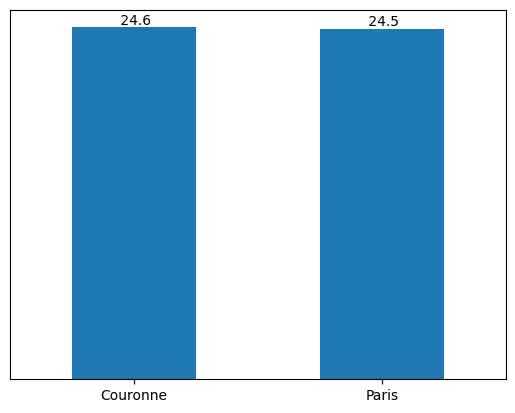

In [46]:
# Visualisation
ax = temp_zone_estival.plot(kind="bar")
# tourner étiquettes axe x
plt.xticks(rotation=0)
# enlever label axe x
plt.xlabel(None)
# enlever graduations axe y
plt.yticks([])
# afficher valeurs au-dessus des barres
for i, v in enumerate(temp_zone_estival):
    ax.text(i, v, f"{v : .1f}", ha='center', va="bottom")
    
plt.show()

Les températures moyennes estivales de Paris et de la couronne sont très proches (autour de 24,5 °C), ce qui suggère une homogénéité thermique à l’échelle globale durant la période estivale.

#### Comparaison temporelle 

In [47]:
# Série temporelle des températures moyennes estivales par zone 
temp_zone_estival_time = df_estival.groupby(['date', 'zone'])['temp_max'].mean().unstack()

In [48]:
# Vérification
temp_zone_estival_time.head()

zone,Couronne,Paris
date,,
2025-05-01,28.800000,29.100000
2025-05-02,27.958537,27.900000
2025-05-03,25.821951,25.966667
2025-05-04,16.734146,16.683333
2025-05-05,15.119512,14.766667


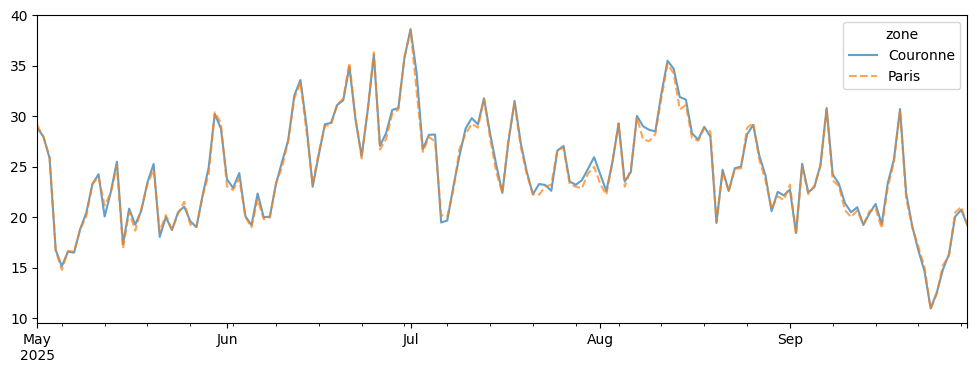

In [49]:
# Visualisation
ax = temp_zone_estival_time.plot(figsize=(12,4), alpha=0.7, style=['-', '--'])
# enlever label axe x
plt.xlabel(None)

plt.show()

Les évolutions temporelles estivales restent similaires entre Paris et la couronne, comme observé sur l'ensemble de la période.


### 4.5 Analyse spatiale locale

#### Comparaison des stations par zone

In [50]:
# Températures moyennes estivales par station dans chaque zone
temp_estival_stations = df_estival.groupby(['zone', 'station'])['temp_max'].mean()
# Classement des stations par température moyenne dans chaque zone
temp_estival_stations = temp_estival_stations.reset_index()
temp_estival_stations = temp_estival_stations.sort_values(by=['zone', 'temp_max'], ascending=[True, False])

In [51]:
# Vérification
temp_estival_stations

,zone,station,temp_max
22,Couronne,NEMOURS,26.139865
6,Couronne,DONNEMARIE,25.769281
19,Couronne,MILLY-LA-FORET,25.706536
23,Couronne,NEUILLY-SUR-M.,25.634641
31,Couronne,ST-MAUR,25.558824
17,Couronne,MAULE,25.454902
13,Couronne,LE PECQ,25.441176
32,Couronne,SURESNES,25.320915
5,Couronne,CROUY-SUR-OURCQ,25.292810
30,Couronne,ST-LOUP-DE-NAUD,25.193464


Les températures moyennes estivales des stations varient entre environ 21,7 °C et 25,9 °C à Paris, et entre 21,9 °C et 26,1 °C en couronne. L'amplitude des températures estivales entre stations apparaît donc similaire dans les deux zones.


#### Stations les plus chaudes par zone en période estivale

In [52]:
# Top 3 des stations les plus chaudes par zone en période estivale
top3_paris_estival = temp_estival_stations[temp_estival_stations['zone']=='Paris'].head(3)
top3_couronne_estival = temp_estival_stations[temp_estival_stations['zone']=='Couronne'].head(3)

In [53]:
# Vérification
display(top3_paris_estival)
print()
display(top3_couronne_estival)

,zone,station,temp_max
43,Paris,LUXEMBOURG,25.882353
42,Paris,LONGCHAMP,25.015033
41,Paris,LARIBOISIERE,25.005882


,zone,station,temp_max
22,Couronne,NEMOURS,26.139865
6,Couronne,DONNEMARIE,25.769281
19,Couronne,MILLY-LA-FORET,25.706536


Une représentation cartographique est réalisée pour situer spatialement les stations les plus chaudes identifiées précédemment, notamment les stations du top 3 dans chaque zone.

Les couleurs représentent des classes de température définies par des seuils simples (23 °C et 25 °C), permettant de distinguer les stations les plus chaudes.

In [55]:
# Carte des stations avec température moyenne en période estivale

# création d'une carte centrée sur Paris
map_paris_estival = folium.Map(location=[48.85, 2.35], zoom_start=10)
# température moyenne estival par station avec coordonnées géographiques
df_map_estival = df_estival.groupby(['zone', 'station', 'lat', 'lon'])['temp_max'].mean().reset_index()
# ajout des stations sur la carte
def get_color_estival(temp):
    if temp > 25:
        return "red"
    elif temp > 23:
        return "orange"
    else:
        return "yellow"
for _, row in df_map_estival.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius = 4 + (row["temp_max"] - 21) * 2, # Taille des cercles = intensité
        color=get_color_estival(row['temp_max']), # Couleur = niveau de température
        fill_opacity=0.6,
        tooltip=f"{row['zone']} - {row['station']} - {row['temp_max']:.1f}°C"
    ).add_to(map_paris_estival)
# sauvegarde de la carte
map_paris_estival.save("../outputs/figures/map_paris_estival.html")

map_paris_estival

On observe l'apparition de plusieurs stations aux températures élevées durant la période estivale, notamment autour de Paris et vers le sud-est de la région (secteur Fontainebleau). Ces regroupements suggèrent des zones potentiellement plus chaudes, sans toutefois permettre une conclusion formelle en raison du nombre limité de stations.

---

## Conclusion 

L'analyse met en évidence une relative homogénéité des températures entre Paris et la couronne à l'échelle globale.

À l'échelle locale, certaines stations se distinguent par des températures plus élevées, révélant des disparités au sein de chaque zone.

En période estivale, ces différences sont accentuées, avec un nombre plus important de stations présentant des températures élevées. Cela suggère la présence de secteurs potentiellement plus exposés à la chaleur.